# Notebook 4 – Full pipeline

**Workflow:** load → filter → epoch rejection → average → export CSV → downstream analysis

This notebook ties together all previous steps into a reproducible end-to-end  
pipeline and shows how to export results for statistical analysis (R, SPSS, seaborn).

**You will learn how to:**
1. Compare the three epoch-rejection methods (amplitude, RMS, correlation).
2. Visualise rejected vs accepted trials.
3. Export per-electrode eCMUAP metrics to a tidy `pandas.DataFrame` / CSV.
4. Do basic downstream visualisation (boxplot, scatter, correlation).


## 1 · Imports & setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecmuap_interface.utils.trigger import Trigger
from ecmuap_interface.core.emg_data import EMGData
from ecmuap_interface.core.HD_emg import HDEMG
from ecmuap_interface.views.HDemg_view import HDEMGView
from ecmuap_interface.views.eCMUAP_view import eCMUAPView
from ecmuap_interface.probe_lib.get_probes import NeuroNexus_H32
from ecmuap_interface.utils.loaders import Ripple_to_array
from ecmuap_interface.utils.probes import make_uniform_probe_from_base
from ecmuap_interface.utils.spatial_filters import IB2_kernel
from ecmuap_interface.utils.export import to_dataframe

DATA_FILE = Path("../data/test_emg.hdf5")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 4)})


## 2 · Load and preprocess (full 32-channel pipeline)

In [2]:
df      = pd.read_hdf(DATA_FILE)
probe   = NeuroNexus_H32()
time    = df["time"].values
data    = Ripple_to_array(df, probe)
trigger = Trigger(df["Tr0 "].values, time)

emg = EMGData(data=data, time=time, trigger=trigger)
emg.HPF(10); emg.notch(50.0); emg.LPF(1_000); emg.remove_baseline()

# Spatial pipeline: interpolate → IB2
uniform_probe = make_uniform_probe_from_base(probe)
hd     = HDEMG(emg=emg, probe=probe)
emg_i  = hd.interpolate_to_probe(uniform_probe)
hd_i   = HDEMG(emg=emg_i, probe=uniform_probe)
emg_f  = hd_i.spatial_filter(IB2_kernel)
hd_f   = HDEMG(emg=emg_f, probe=uniform_probe)
view_f = HDEMGView(hd_f)

T_PRE, T_POST = 1e-3, 15e-3
print("Pipeline ready.")


Pipeline ready.


## 3 · Epoch rejection

Automatic rejection removes artefact-contaminated trials before averaging.  
Three criteria are available:

| Method | Criterion | Threshold (auto) |
|--------|-----------|-----------------|
| `amplitude` | `max(|signal|)` across all channels | 3 × median score |
| `rms` | RMS across all channels | 3 × median score |
| `correlation` | 1 − Pearson r with template | median + 3 × MAD |

All three are compared below.  Tighter `auto_scale` (e.g. 2.5) rejects more aggressively.


In [3]:
view_raw = eCMUAPView(emg_f)

results = {}
for method in ("amplitude", "rms", "correlation"):
    clean, mask = view_raw.reject_epochs(
        T_PRE, T_POST, skip_start=3, skip_end=3,
        method=method, return_mask=True,
    )
    n_total    = mask.size
    n_rejected = int((~mask).sum())
    results[method] = {"mask": mask, "n_rejected": n_rejected, "n_total": n_total}
    print(f"{method:12s}: {n_rejected}/{n_total} rejected")


amplitude   : 0/53 rejected
rms         : 0/53 rejected
correlation : 0/53 rejected


### 3.1 · Visualise accepted vs rejected epochs (amplitude method)

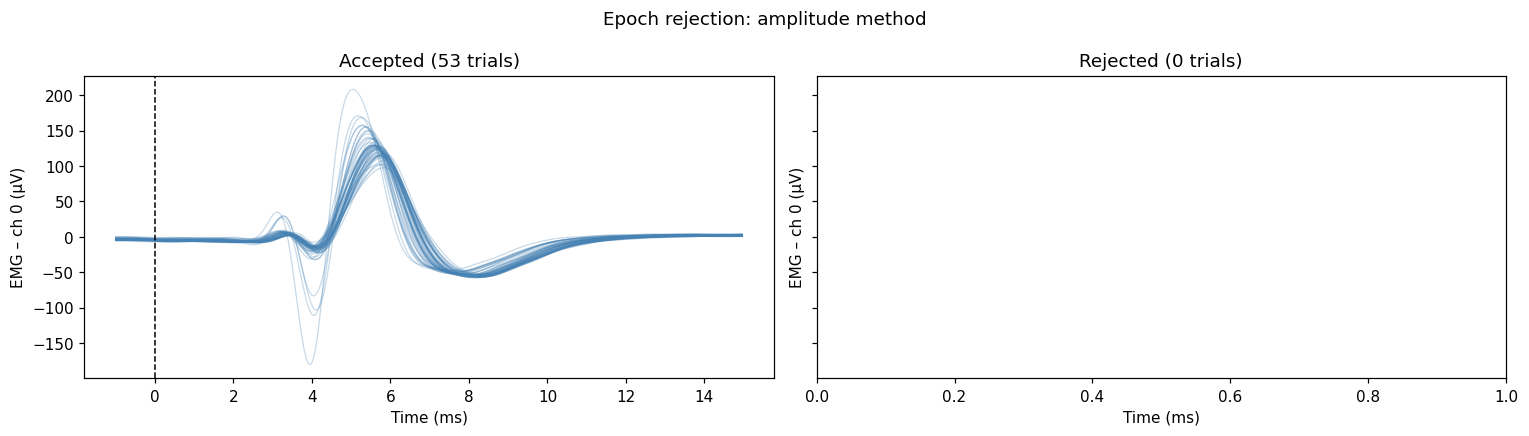

In [4]:
method = "amplitude"
mask   = results[method]["mask"]

all_epochs = view_raw.epochs(T_PRE, T_POST, skip_start=3, skip_end=3)
epoch_t    = np.linspace(-T_PRE, T_POST, all_epochs.shape[2], endpoint=False) * 1e3

# Use channel 0 for illustration
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (label, sel) in zip(axes, [("Accepted", mask), ("Rejected", ~mask)]):
    idx = np.where(sel)[0]
    color = "steelblue" if label == "Accepted" else "crimson"
    for i in idx:
        ax.plot(epoch_t, all_epochs[i, 0], color=color, alpha=0.3, lw=0.8)
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_title(f"{label} ({len(idx)} trials)")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("EMG – ch 0 (µV)")

plt.suptitle(f"Epoch rejection: amplitude method", fontsize=12)
plt.tight_layout()


## 4 · Average eCMUAP with and without rejection

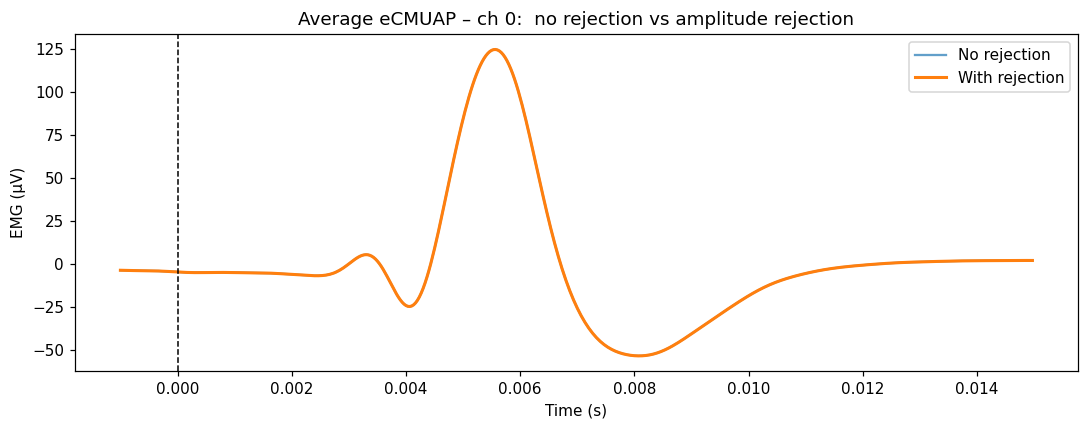

In [5]:
avg_no_rej = view_raw.average(T_PRE, T_POST, skip_start=3, skip_end=3, reject=False)
avg_reject = view_raw.average(T_PRE, T_POST, skip_start=3, skip_end=3,
                              reject=True, reject_method="amplitude")

epoch_t_s = np.linspace(-T_PRE, T_POST, avg_no_rej.shape[1], endpoint=False)

ch = 0
fig, ax = plt.subplots()
ax.plot(epoch_t_s, avg_no_rej[ch], label="No rejection", alpha=0.7, lw=1.5)
ax.plot(epoch_t_s, avg_reject[ch],  label="With rejection", lw=2)
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("EMG (µV)")
ax.set_title(f"Average eCMUAP – ch {ch}:  no rejection vs amplitude rejection")
ax.legend()
plt.tight_layout()


## 5 · Export per-electrode metrics to CSV

`to_dataframe` collects per-electrode amplitude and timing metrics into a  
tidy `pandas.DataFrame` — one row per electrode, ready for R / SPSS / seaborn.

Setting `include_velocity=True` adds `delay_ms` and `speed_ms` columns  
(requires a uniform-grid probe with `pitch_um` annotation).


In [6]:
df_metrics = to_dataframe(
    view_f,
    t_pre=T_PRE,
    t_post=T_POST,
    skip_start=3,
    skip_end=3,
    filter_label="IB2",
    reject=True,
    reject_method="amplitude",
    include_velocity=True,
)

print(df_metrics.shape)
df_metrics.head(6)


(34, 15)


,electrode_id,x_um,y_um,rms_uV,ptp_uV,peak_uV,latency_ms,duration_ms,ttmin_ms,ttmax_ms,delay_ms,speed_ms,filter,t_pre_s,t_post_s
0,0,-4464.000000,-7000.0,37.287417,177.688113,124.531602,3.766667,6.533333,8.066667,5.566667,9.066667,0.461630,IB2,0.001,0.015
1,1,-2737.834017,-7000.0,118.964467,669.852824,473.894742,3.466667,3.866667,4.400000,5.966667,5.400000,0.784170,IB2,0.001,0.015
2,2,-1011.668035,-7000.0,202.408620,1143.319501,829.341072,3.433333,3.700000,4.333333,5.866667,5.333334,1.608683,IB2,0.001,0.015
3,3,714.497948,-7000.0,214.780695,1255.109006,854.673160,3.266667,3.633333,4.166667,5.733333,5.166667,1.665073,IB2,0.001,0.015
4,4,2440.663931,-7000.0,182.409787,1115.519088,692.242625,3.266667,3.500000,4.166667,5.666667,5.166667,1.917626,IB2,0.001,0.015
5,5,4166.829914,-7000.0,55.471364,284.489541,196.540168,3.166667,6.700000,4.133333,5.433333,5.133334,1.916641,IB2,0.001,0.015


In [7]:
# Save to CSV next to the data file
out_csv = DATA_FILE.parent / "results_IB2.csv"
df_metrics.to_csv(out_csv, index=False)
print(f"Saved → {out_csv}")


Saved → ../data/results_IB2.csv


## 6 · Downstream analysis

### 6.1 · Amplitude distribution per electrode

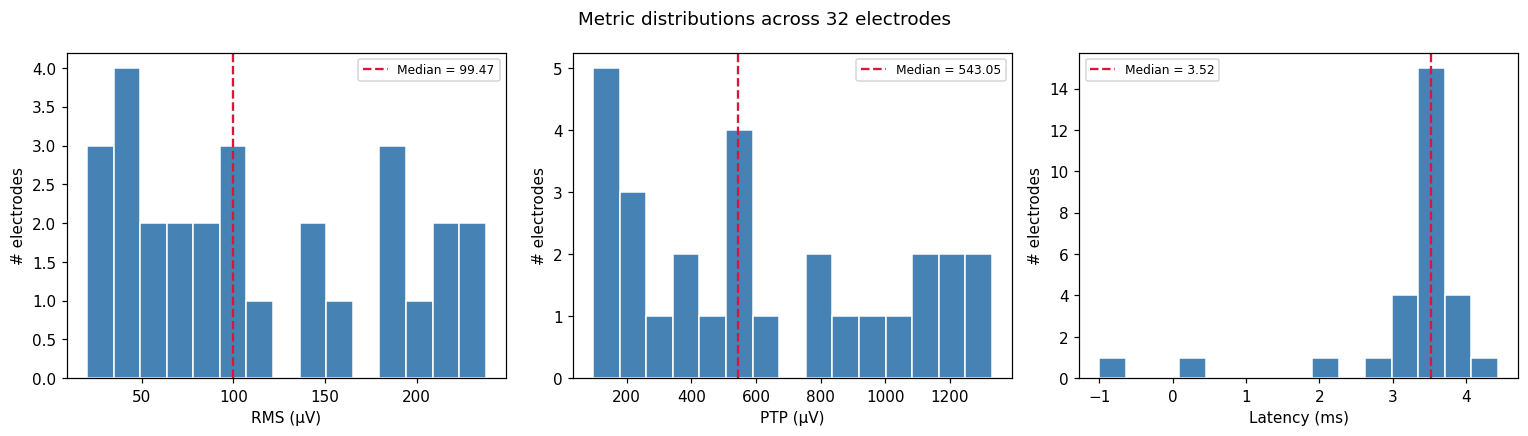

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(axes,
    ["rms_uV",  "ptp_uV",  "latency_ms"],
    ["RMS (µV)", "PTP (µV)", "Latency (ms)"]
):
    vals = df_metrics[col].dropna()
    ax.hist(vals, bins=15, color="steelblue", edgecolor="white")
    ax.axvline(vals.median(), color="crimson", ls="--", lw=1.5, label=f"Median = {vals.median():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("# electrodes")
    ax.legend(fontsize=8)

plt.suptitle("Metric distributions across 32 electrodes", fontsize=12)
plt.tight_layout()


### 6.2 · Spatial scatter: RMS vs electrode position

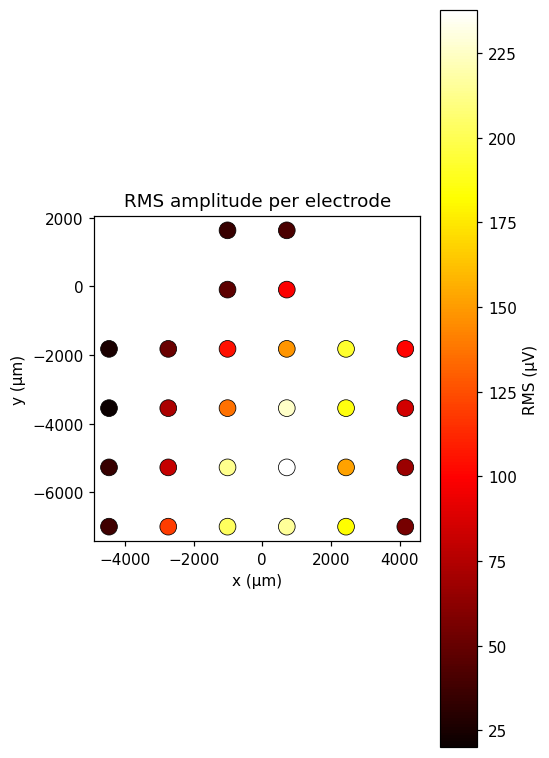

In [9]:
fig, ax = plt.subplots(figsize=(5, 7))
sc = ax.scatter(
    df_metrics["x_um"], df_metrics["y_um"],
    c=df_metrics["rms_uV"], cmap="hot",
    s=120, edgecolors="k", linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label="RMS (µV)")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("RMS amplitude per electrode")
ax.set_aspect("equal")
plt.tight_layout()


### 6.3 · Correlation: RMS vs CV speed

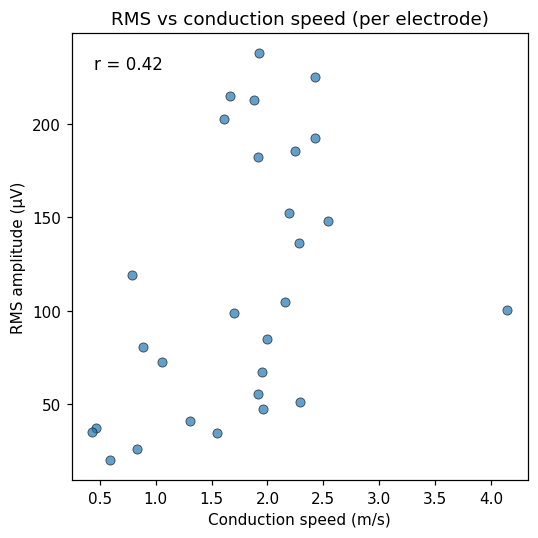

In [10]:
sub = df_metrics[["rms_uV", "speed_ms"]].dropna()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sub["speed_ms"], sub["rms_uV"], alpha=0.7, edgecolors="k", lw=0.5)
ax.set_xlabel("Conduction speed (m/s)")
ax.set_ylabel("RMS amplitude (µV)")
ax.set_title("RMS vs conduction speed (per electrode)")

# Pearson r
r = np.corrcoef(sub["speed_ms"], sub["rms_uV"])[0, 1]
ax.text(0.05, 0.92, f"r = {r:.2f}", transform=ax.transAxes, fontsize=11)
plt.tight_layout()


## 7 · Summary – full pipeline

```
HDF5 file
  └─ Ripple_to_array + NeuroNexus_H32
       └─ EMGData (HPF → notch → LPF → remove_baseline)
            └─ HDEMG.interpolate_to_probe (uniform grid)
                 └─ HDEMG.spatial_filter(IB2_kernel)
                      └─ HDEMGView
                           ├─ eCMUAPView.reject_epochs   → clean epochs
                           ├─ eCMUAPView.average          → avg eCMUAP
                           └─ to_dataframe                → results.csv
```

| Notebook | Topic |
|----------|-------|
| [01](01_single_channel_eCMUAP.ipynb) | Single-channel eCMUAP basics |
| [02](02_HD_emg.ipynb) | HD-EMG spatial analysis |
| [03](03_conduction_velocity.ipynb) | Conduction velocity |
| **04** | **Full pipeline + CSV export** |
